In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [9]:
bg_image1 = cv2.cvtColor(cv2.imread('data/background1.png'), cv2.COLOR_BGR2RGB)
ob_image  = cv2.cvtColor(cv2.imread('data/object.png'),      cv2.COLOR_BGR2RGB)
bg_image2 = cv2.cvtColor(cv2.imread('data/background2.png'), cv2.COLOR_BGR2RGB)

print('bg_image1:', bg_image1.shape)
print('ob_image :', ob_image.shape)
print('bg_image2:', bg_image2.shape)

bg_image1: (699, 964, 3)
ob_image : (699, 964, 3)
bg_image2: (495, 880, 3)


# Create Masking

Diff_single_chan: (699, 964)


(np.float64(-0.5), np.float64(963.5), np.float64(698.5), np.float64(-0.5))

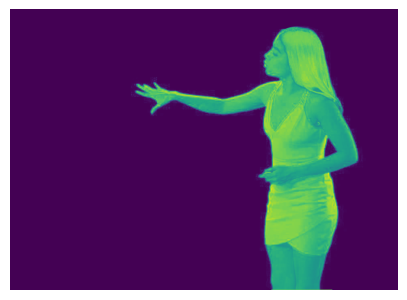

In [19]:
a = ob_image.astype(np.int32)
b = bg_image1.astype(np.int32)

# Difference
difference = np.abs(b - a)
# print(f"Diff {difference}")

# Merge 3 channel -> 1 channel
difference_single_channel = difference.sum(axis=2)
print(f"Diff_single_chan: {difference_single_channel.shape}")

plt.figure(figsize=(5,5))
plt.imshow(difference_single_channel)
plt.axis('off')

# Compute Binary

Ty le pixel thuoc doi tuong: 18.10%


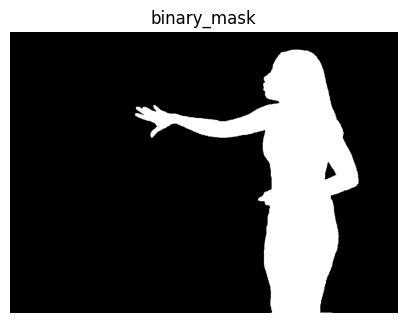

In [22]:
threshold = 50

binary_mask = (difference_single_channel > threshold).astype(np.uint8)


print('Ty le pixel thuoc doi tuong: {:.2f}%'.format(100.0 * binary_mask.mean()))


plt.figure(figsize=(5, 5))
plt.imshow(binary_mask * 255, cmap='gray', vmin=0, vmax=255)
plt.title('binary_mask')
plt.axis('off'); plt.show()

# Replace background